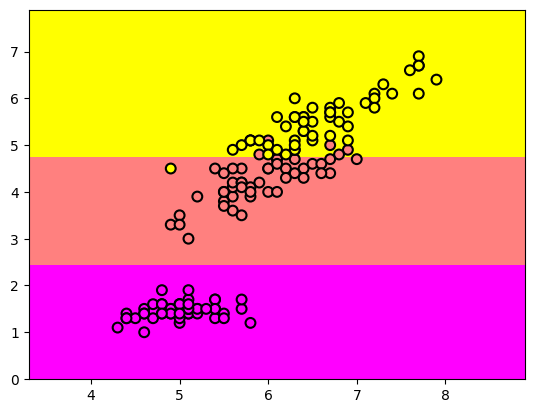

In [1]:
# Решающее дерево для задачи классификации

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import datasets


def get_grid(data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    return np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))


iris = datasets.load_iris()
train_data = np.c_[iris.data[:, 0].reshape(-1, 1), iris.data[:, 2].reshape(-1, 1)]
train_labels = iris.target

clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=5)
clf_tree.fit(train_data, train_labels)

# plot_tree(clf_tree)

xx, yy = get_grid(train_data)
predicted = clf_tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, predicted, cmap='spring', shading='auto')
plt.scatter(train_data[:, 0], train_data[:, 1], c=train_labels, s=50, cmap='spring', edgecolors='black', linewidth=1.5)
plt.show()